В цьому домашньому завданні ми побудуємо рішення задачі логістичної регресії і створимо ваш перший submission на змагання на Kaggle. Усі кроки були розглянуті в лекції та містяться в ноутбуці `Логістична регресія з ScikitLearn. Повна ML задача.ipynb`, але тепер ми їх адаптуємо до іншої задачі - все як в реальному житті, коли ви знайшли код у відкритих джерелах і адаптуєте на проєкті 😉

**Погнали! 🚀🚀🚀**

-----------



0. Завантажте дані `train.csv`, `test.csv`, `sample_submission.csv` зі змагання на Kaggle - шукайте посилання в уроці [Запрошення до участі у Kaggle-змаганні.](https://data-loves.kwiga.com/courses/machine-learning-dlia-liudei/domashnie-zavdannia-zmagannia-z-kaggle) Для завантаження потрібно долучитись до змагання (натиснути кнопку "Join").

1. Зчитайте дані `train.csv` в pandas dataframe та розбийте їх на train і validation піднабори.

  * Є такий параметр в методі train_test_split як stratified. Можливо він буде Вам корисним при розбитті даних в цій задачі. Пропоную Вам почитати про нього в документації і спробувати скористатись.

In [118]:
#import opendatasets as od

In [119]:
#dataset_url = 'https://www.kaggle.com/competitions/bank-customer-churn-prediction-dlu-course-c-3/data'

In [120]:
#od.download(dataset_url)

In [121]:
import os

In [122]:
data_dir = './bank-customer-churn-prediction-dlu-course-c-3'

In [123]:
os.listdir(data_dir)

['test.csv', 'train.csv', '.ipynb_checkpoints', 'sample_submission.csv']

In [124]:
train_csv = data_dir + '/train.csv'

In [125]:
import pandas as pd
import matplotlib.pyplot as plt

In [126]:
raw_df = pd.read_csv(train_csv)

In [127]:
raw_df.head()

,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,0,15779985.0,Nwankwo,678.0,France,Male,29.0,4.0,0.00,3.0,1.0,0.0,180626.36,0.0
1,1,15650086.0,Ch'in,687.0,France,Female,34.0,1.0,0.00,2.0,0.0,1.0,63736.17,0.0
2,2,15733602.0,Thompson,682.0,France,Female,52.0,6.0,0.00,3.0,0.0,0.0,179655.87,1.0
3,3,15645794.0,Macleod,753.0,Germany,Male,44.0,6.0,83347.25,2.0,1.0,0.0,161407.48,0.0
4,4,15633840.0,Hsia,544.0,Germany,Female,55.0,0.0,107747.57,1.0,1.0,0.0,176580.86,1.0


In [128]:
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               15000 non-null  int64  
 1   CustomerId       15000 non-null  float64
 2   Surname          15000 non-null  object 
 3   CreditScore      15000 non-null  float64
 4   Geography        15000 non-null  object 
 5   Gender           15000 non-null  object 
 6   Age              15000 non-null  float64
 7   Tenure           15000 non-null  float64
 8   Balance          15000 non-null  float64
 9   NumOfProducts    15000 non-null  float64
 10  HasCrCard        15000 non-null  float64
 11  IsActiveMember   15000 non-null  float64
 12  EstimatedSalary  15000 non-null  float64
 13  Exited           15000 non-null  float64
dtypes: float64(10), int64(1), object(3)
memory usage: 1.6+ MB


Розділимо дані на тренувальний і валідаційний сети

In [129]:
from sklearn.model_selection import train_test_split

In [130]:
train_df, val_df = train_test_split(raw_df, test_size=0.2, random_state=42, stratify = raw_df['Exited'])

In [131]:
print('train_df.shape :', train_df.shape)
print('val_df.shape :', val_df.shape)

train_df.shape : (12000, 14)
val_df.shape : (3000, 14)


Перевіримо співвідношення значень таргет-колонки Exited в двох наборах даних після використання stratify:

In [132]:
print(train_df['Exited'].value_counts(normalize=True))

Exited
0.0    0.7965
1.0    0.2035
Name: proportion, dtype: float64


In [133]:
print(val_df['Exited'].value_counts(normalize=True))

Exited
0.0    0.796667
1.0    0.203333
Name: proportion, dtype: float64


2. Визначіть назви колонок, які сформують вхідні незалежні дані, в змінній `input_cols` та назву колонки , яка є цільовою, в змінній `target_col`. Використовуючи `input_cols` та `target_col` створіть набори даних `train_inputs`, `train_targets`, `val_inputs`, `val_targets` - де `inputs` - вхідні дані (датафрейм), `targets` - дані цільової колонки відповідного піднабору.

In [134]:
input_cols = list(train_df.columns)[1:-1]
target_col = 'Exited'

In [135]:
print(input_cols)

['CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary']


In [136]:
target_col

'Exited'

In [137]:
train_inputs = train_df[input_cols].copy()
train_targets = train_df[target_col].copy()

In [138]:
val_inputs = val_df[input_cols].copy()
val_targets = val_df[target_col].copy()

3. Визначіть з допомогою `pandas.DataFrame.select_dtypes` назви колонок, які є числовими і категоріальними. Запишіть результати в `numeric_cols` та `categorical_cols` відповідно.

In [139]:
import numpy as np

In [140]:
numeric_cols = train_inputs.select_dtypes(include=np.number).columns.tolist()
categorical_cols = train_inputs.select_dtypes('object').columns.tolist()

In [141]:
numeric_cols, categorical_cols

(['CustomerId',
  'CreditScore',
  'Age',
  'Tenure',
  'Balance',
  'NumOfProducts',
  'HasCrCard',
  'IsActiveMember',
  'EstimatedSalary'],
 ['Surname', 'Geography', 'Gender'])

4. Зробіть підготовку даних в категоріальних і числових колонках для входу в модель виходячи з освоєного на даний момент на курсі. Варіанти пеердобробки, з якими ми вже знайомі:
  - масштабування числових ознак,
  - заповнення пропущених значень, якщо вони є,
  - кодування категоріальних ознак, вилучення ознак, якщо ми вважаємо, що ці дані нерелевантні для моделі аби ми не бачимо способу як їх так закодувати, аби подати на вхід моделі.

  Тут є багато варіантів, як Ви побудуєте передобробку, важливо аби
  1) передобробка мала сенс (немає сенсу заповнювати дані константою, яку ми не зрозуміло звідки взяли)   
  2) має бути виконана принаймні одна дія передобробки
  3) обробка маэ бути виконана коректно і для тренувальних, і для вал. даних
  4) чим вищий у Вас врешті вийде ROС AUC скор, тим більше шансів перемогти у змаганні :)

  Опишіть рішення проведення кожного з кроків передобробки. Для чого ви його робите? По завершенню виведіть по 5 значен з `train_inputs`, `val_inputs` використовуючи `display()`.

Так як пропущених значень немає, немає необхідності проводити імпутацію  

In [142]:
train_inputs[train_inputs['EstimatedSalary'] < 100]

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
7232,15651460.0,Milanesi,718.0,Germany,Female,35.0,8.0,123953.31,1.0,1.0,0.0,11.58
12856,15660211.0,Okeke,661.0,France,Male,36.0,2.0,122924.75,1.0,1.0,0.0,11.58


Ці два рядки виглядають трохи підозріло 😅 ці клієнти мають низький (до того ж однаковий) дохід, можливо, якийсь плейсхолдер, але поки залишимо ці дані. пізніше можна буде спробувати проаналізувати, що відбуватиметься 

Колонки **Surname** та **CustomerId** є унікальними ідентифікаторами клієнтів, і аж ніяк не будуть мати релевантного впливу на нашу модель, тому одразу викинемо їх

In [143]:
columns_to_drop = ['CustomerId', 'Surname']
train_inputs.drop(columns = columns_to_drop, inplace = True)
val_inputs.drop(columns = columns_to_drop, inplace = True)

In [144]:
val_inputs.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
6490,714.0,Germany,Male,46.0,1.0,115764.32,4.0,1.0,1.0,72945.32
3646,593.0,France,Male,41.0,5.0,0.00,2.0,1.0,1.0,38196.24
5306,731.0,France,Female,38.0,2.0,0.00,2.0,0.0,1.0,116971.05
652,673.0,France,Female,43.0,4.0,155739.76,1.0,0.0,1.0,111622.76
2627,678.0,Spain,Female,30.0,4.0,0.00,2.0,1.0,0.0,143681.85


Оновимо numerical i categotical колонки після відкидання **Surname** та **CustomerId**

In [145]:
numeric_cols = train_inputs.select_dtypes(include=np.number).columns.tolist()
categorical_cols = train_inputs.select_dtypes('object').columns.tolist()

#### Робота з числовими колонками

Тепер попрацюємо над числовими колонками  
Проведемо масшабування числових ознак

In [146]:
train_inputs[numeric_cols].describe().round(2)

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
count,12000.00,12000.00,12000.00,12000.00,12000.00,12000.00,12000.00,12000.00
mean,658.84,37.69,5.03,43008.17,1.59,0.79,0.49,117992.40
std,72.33,8.14,2.78,59906.63,0.53,0.41,0.50,45589.48
min,431.00,18.00,0.00,0.00,1.00,0.00,0.00,11.58
25%,603.00,32.00,3.00,0.00,1.00,1.00,0.00,83343.73
50%,661.00,37.00,5.00,0.00,2.00,1.00,0.00,123613.91
75%,708.00,42.00,7.00,109949.05,2.00,1.00,1.00,156912.81
max,850.00,74.00,10.00,209767.31,4.00,1.00,1.00,199992.48


In [147]:
from sklearn.preprocessing import MinMaxScaler

In [148]:
scaler = MinMaxScaler()

In [149]:
scaler.fit(train_inputs[numeric_cols])

MinMaxScaler()

In [150]:
train_inputs[numeric_cols] = scaler.transform(train_inputs[numeric_cols])
val_inputs[numeric_cols] = scaler.transform(val_inputs[numeric_cols])

In [151]:
train_inputs.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
7180,0.599045,France,Male,0.214286,0.1,0.626382,0.000000,1.0,1.0,0.719772
10393,0.603819,France,Female,0.375000,0.2,0.848836,0.000000,1.0,0.0,0.727603
80,0.653938,Germany,Male,0.303571,0.6,0.554522,0.333333,1.0,0.0,0.872180
3365,0.568019,Spain,Male,0.714286,0.0,0.000000,0.333333,0.0,1.0,0.257797
12236,0.658711,France,Male,0.053571,0.3,0.000000,0.333333,1.0,1.0,0.742837


#### Робота з категоріальними колонками

In [152]:
train_inputs[categorical_cols].nunique()

Geography    3
Gender       2
dtype: int64

Закодимо значення колонок, що лишилися за допомогою OneHotEncoder  
***питання**: так як Gender бінарна колонка, не краще було б кодувати її вручну? зараз я передаю як є, бо OneHotEncoder просить двовимірний масив, але цілому як краще було б робити? змінити розмірність для Geography чи це ок закодити через OHE і Gender?*

In [153]:
from sklearn.preprocessing import OneHotEncoder

In [154]:
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

In [155]:
encoder.fit(train_inputs[categorical_cols])

OneHotEncoder(handle_unknown='ignore', sparse_output=False)

In [156]:
encoder.categories_

[array(['France', 'Germany', 'Spain'], dtype=object),
 array(['Female', 'Male'], dtype=object)]

In [157]:
encoded_cols = list(encoder.get_feature_names_out(categorical_cols))
print(encoded_cols)

['Geography_France', 'Geography_Germany', 'Geography_Spain', 'Gender_Female', 'Gender_Male']


In [158]:
encoder.transform(train_inputs[categorical_cols])[:10]

array([[1., 0., 0., 0., 1.],
       [1., 0., 0., 1., 0.],
       [0., 1., 0., 0., 1.],
       [0., 0., 1., 0., 1.],
       [1., 0., 0., 0., 1.],
       [0., 1., 0., 1., 0.],
       [1., 0., 0., 0., 1.],
       [0., 1., 0., 0., 1.],
       [0., 1., 0., 0., 1.],
       [1., 0., 0., 1., 0.]])

In [159]:
train_inputs[encoded_cols] = encoder.transform(train_inputs[categorical_cols])
val_inputs[encoded_cols] = encoder.transform(val_inputs[categorical_cols])

In [160]:
train_inputs

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_France,Geography_Germany,Geography_Spain,Gender_Female,Gender_Male
7180,0.599045,France,Male,0.214286,0.1,0.626382,0.000000,1.0,1.0,0.719772,1.0,0.0,0.0,0.0,1.0
10393,0.603819,France,Female,0.375000,0.2,0.848836,0.000000,1.0,0.0,0.727603,1.0,0.0,0.0,1.0,0.0
80,0.653938,Germany,Male,0.303571,0.6,0.554522,0.333333,1.0,0.0,0.872180,0.0,1.0,0.0,0.0,1.0
3365,0.568019,Spain,Male,0.714286,0.0,0.000000,0.333333,0.0,1.0,0.257797,0.0,0.0,1.0,0.0,1.0
12236,0.658711,France,Male,0.053571,0.3,0.000000,0.333333,1.0,1.0,0.742837,1.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9493,0.482100,France,Female,0.267857,0.4,0.000000,0.333333,0.0,0.0,0.617686,1.0,0.0,0.0,1.0,0.0
8463,0.577566,France,Female,0.392857,0.1,0.000000,0.000000,1.0,1.0,0.239129,1.0,0.0,0.0,1.0,0.0
8143,0.453461,France,Male,0.196429,0.8,0.000000,0.333333,1.0,1.0,0.667682,1.0,0.0,0.0,0.0,1.0
11512,0.379475,Spain,Male,0.428571,0.7,0.000000,0.333333,0.0,0.0,0.363197,0.0,0.0,1.0,0.0,1.0


5. Збережіть дані, що містяться в змінних `train_inputs`, `train_targets`, `val_inputs`, `val_targets` на диск в форматі `parquet`. В кінці виведіть список файлів в папці, в яку Ви зберегли файли і перевірте, чи файли збереглись. Вивести список файлів можна з `os.listdir(your_dir)` або `!ls your_dir`

In [161]:
print('train_inputs:', train_inputs.shape)
print('train_targets:', train_targets.shape)
print('val_inputs:', val_inputs.shape)
print('val_targets:', val_targets.shape)

train_inputs: (12000, 15)
train_targets: (12000,)
val_inputs: (3000, 15)
val_targets: (3000,)


In [162]:
train_inputs.to_parquet('train_inputs.parquet')
val_inputs.to_parquet('val_inputs.parquet')

In [163]:
pd.DataFrame(train_targets).to_parquet('train_targets.parquet')
pd.DataFrame(val_targets).to_parquet('val_targets.parquet')

In [164]:
os.listdir()

['bank-customer-churn-prediction-dlu-course-c-3',
 'train_targets.parquet',
 '.DS_Store',
 'HW_2_2_Поліноміальні_ознаки_Pipelines.ipynb',
 'regression_data.csv',
 'train_inputs.parquet',
 'customer_churns_p4.joblib',
 'val_inputs.parquet',
 '.ipynb_checkpoints',
 'HW_2_2_Логістична_регресія_з_scikit_learn.ipynb',
 'customer_churns.joblib',
 'customer_churn.joblib',
 'val_targets.parquet',
 'customer_churns_p.joblib']

Зчитуємо паркет

In [165]:
import pandas as pd
import numpy as np

In [166]:
target_col = 'Exited'

In [167]:
%%time

train_inputs = pd.read_parquet('train_inputs.parquet')
val_inputs = pd.read_parquet('val_inputs.parquet')

train_targets = pd.read_parquet('train_targets.parquet')[target_col]
val_targets = pd.read_parquet('val_targets.parquet')[target_col]


CPU times: user 23.3 ms, sys: 10.6 ms, total: 33.9 ms
Wall time: 20.3 ms


In [168]:
print('train_inputs:', train_inputs.shape)
print('train_targets:', train_targets.shape)
print('val_inputs:', val_inputs.shape)
print('val_targets:', val_targets.shape) 

train_inputs: (12000, 15)
train_targets: (12000,)
val_inputs: (3000, 15)
val_targets: (3000,)


6. З підготовлених вхіжних даних створіть `X_train`, `X_val` набори, які містять лише колонки, які підуть на вхід моделі. Навчіть модель бінарної класифікації з допомогою `LogisticRegression` в `scikit-learn`.

In [171]:
from sklearn.linear_model import LogisticRegression

In [172]:
X_train = train_inputs[numeric_cols + encoded_cols]
X_val = val_inputs[numeric_cols + encoded_cols]

In [173]:
model = LogisticRegression(solver='liblinear')

In [174]:
model.fit(X_train, train_targets)

LogisticRegression(solver='liblinear')

In [175]:
train_preds = model.predict(X_train)

In [176]:
train_preds

array([0., 0., 0., ..., 0., 0., 0.])

In [177]:
val_preds = model.predict(X_val)

In [178]:
val_preds

array([0., 0., 0., ..., 0., 0., 0.])

7. Виведіть Confusion matrix, ROC Curve, метрику AUROC та метрику F1 Score для порога класифікації 0.5 для побудованої моделі на тренувальних та валідаційних даних. Що можете сказати про якіст моделі? Вона хороша, погана, задовільна?

#### confusion matrix

In [179]:
from sklearn.metrics import confusion_matrix

In [180]:
confusion_matrix(train_targets, train_preds)

array([[9177,  381],
       [1128, 1314]])

In [181]:
train_targets.value_counts()

Exited
0.0    9558
1.0    2442
Name: count, dtype: int64

Бачимо, що приблизно 46% значень False Negative, не дуже подобається такий результат

In [182]:
confusion_matrix(val_targets, val_preds)

array([[2271,  119],
       [ 266,  344]])

#### f1 score

In [183]:
from sklearn.metrics import f1_score

In [184]:
preds = model.predict(X_train)

In [185]:
f1_score(train_targets, preds)

0.6352429296591733

In [186]:
def get_f1_score(inputs, targets, name=''):
  preds = model.predict(inputs)

  f1_score_ = f1_score(targets, preds)
  print(f"F1 score {name}: {f1_score_:.2f}%")

get_f1_score(X_train, train_targets, 'Training')
get_f1_score(X_val, val_targets, 'Validation')

F1 score Training: 0.64%
F1 score Validation: 0.64%


##### ROC Curve, метрика AUROC

In [187]:
from sklearn.metrics import roc_curve, auc

def compute_auroc_and_build_roc(inputs, targets, name=''):
  # Predict probabilities
  y_pred_proba = model.predict_proba(inputs)[:, 1]

  # Compute ROC curve
  fpr, tpr, thresholds = roc_curve(targets, y_pred_proba)

    # Compute AUROC
  roc_auc = auc(fpr, tpr)
  print(f'AUROC for {name}: {roc_auc:.2f}')

  # Plot the ROC curve
  plt.figure()
  plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
  plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
  plt.xlim([0.0, 1.0])
  plt.ylim([0.0, 1.05])
  plt.xlabel('False Positive Rate')
  plt.ylabel('True Positive Rate')
  plt.title(f'Receiver Operating Characteristic (ROC) Curve for {name}')
  plt.legend(loc="lower right")
  plt.show()

AUROC for Training: 0.88


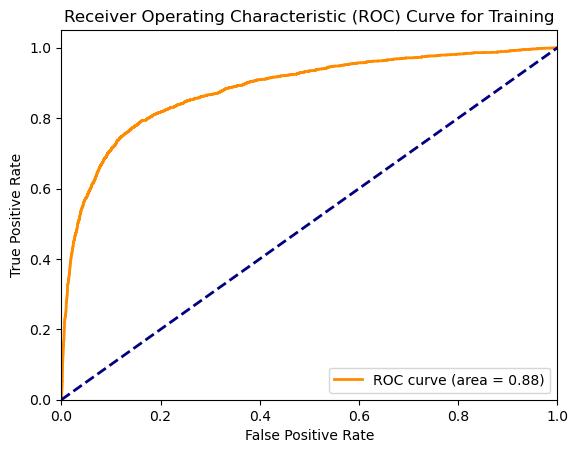

AUROC for Validation: 0.88


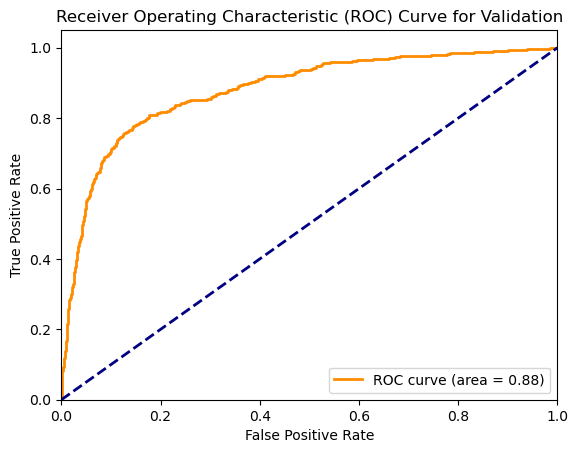

In [188]:
compute_auroc_and_build_roc(X_train, train_targets, 'Training')
compute_auroc_and_build_roc(X_val, val_targets, 'Validation')

8. Створіть передбачення моделі, яка передбачає завжди мажоритарний клас (той, якого більше в тренувальних даних). Порахуйте Accuracy на тренувальних та валідаційних даних для цієї моделі і тої, що ми натренували в п.6. Зробіть заключення про якість нашої моделі: якість хороша, погана, задовільна?

In [189]:
def all_null(inputs):
    return np.full(len(inputs), 0)

In [190]:
from sklearn.metrics import accuracy_score

In [191]:
accuracy_score(train_targets, all_null(X_train))

0.7965

In [192]:
accuracy_score(val_targets, all_null(X_val))

0.7966666666666666

In [193]:
accuracy_score(train_targets, train_preds)

0.87425

Ну, можемо сказати, що наша модель краща за базову 😁  
Загалом вона демонструє стабільну якість як на тренувальних, так і на валідаційних даних.
За результатами основних метрик можемо сказати, що модель є доволі непоганою. Однак велика кількість false negatives змушує замислитися над покращенням чи змінами в моделі, наприклад, зміною порогу класифікації.

9. Збережіть модель і інші обʼєкти, які ви хотіли б зберегти, з використанням бібліотеки joblib в файл `log_reg.joblib`. Потім завантажте модель з файлу в змінну `model_2` (цим ми тренуємось завантажувати модель з файлу на майбутнє).

In [194]:
import joblib

In [195]:
customer_churn = {
    'model': model,
    'scaler': scaler,
    'encoder': encoder,
    'input_cols': input_cols,
    'target_col': target_col,
    'numeric_cols': numeric_cols,
    'categorical_cols': categorical_cols,
    'encoded_cols': encoded_cols
}

In [196]:
joblib.dump(customer_churn, 'customer_churn.joblib')

['customer_churn.joblib']

In [197]:
model_2 = joblib.load('customer_churn.joblib')

In [198]:
model_2

{'model': LogisticRegression(solver='liblinear'),
 'scaler': MinMaxScaler(),
 'encoder': OneHotEncoder(handle_unknown='ignore', sparse_output=False),
 'input_cols': ['CustomerId',
  'Surname',
  'CreditScore',
  'Geography',
  'Gender',
  'Age',
  'Tenure',
  'Balance',
  'NumOfProducts',
  'HasCrCard',
  'IsActiveMember',
  'EstimatedSalary'],
 'target_col': 'Exited',
 'numeric_cols': ['CreditScore',
  'Age',
  'Tenure',
  'Balance',
  'NumOfProducts',
  'HasCrCard',
  'IsActiveMember',
  'EstimatedSalary'],
 'categorical_cols': ['Geography', 'Gender'],
 'encoded_cols': ['Geography_France',
  'Geography_Germany',
  'Geography_Spain',
  'Gender_Female',
  'Gender_Male']}

10. Ознайомтесь з роботою наведеної функції `predict_raw_df`. Ця функція робить підготовку даних (масштабування числових колонок і кодування категоріальних) і виводить ймовірності належності до класу 1 для кожного рядка в наданому наборі.

Доповніть або внесіть зміни у функцію з врахуванням вашого препроцесингу даних.

In [202]:
import warnings
warnings.filterwarnings("ignore")

def predict_raw_df(scaler, encoder, numeric_cols, categorical_cols, input_df: pd.DataFrame):
    columns_to_drop = ['CustomerId', 'Surname']
    input_df = input_df.drop(columns=columns_to_drop) 
    
    input_df[numeric_cols] = scaler.transform(input_df[numeric_cols])
    input_df[encoded_cols] = encoder.transform(input_df[categorical_cols])
    
    X_input = input_df[numeric_cols + encoded_cols]
    prob = model.predict_proba(X_input)[:,1]
    return prob

11. Зчитайте дані з `test.csv` в змінну `test_raw_df`. Зробіть передбачення для кожного рядка даних з функцією з попереднього завдання і запишіть результат в нову колонку `Exited` в датафреймі `test_raw_df`.

In [219]:
test_raw_df = pd.read_csv('./bank-customer-churn-prediction-dlu-course-c-3/test.csv')
test_raw_df.head()

,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,15000,15594796.0,Chu,584.0,Germany,Male,30.0,2.0,146053.66,1.0,1.0,1.0,157891.86
1,15001,15642821.0,Mazzi,551.0,France,Male,39.0,5.0,0.00,2.0,1.0,1.0,67431.28
2,15002,15716284.0,Onyekachi,706.0,France,Male,43.0,8.0,0.00,2.0,1.0,0.0,156768.45
3,15003,15785078.0,Martin,717.0,Spain,Male,45.0,3.0,0.00,1.0,1.0,1.0,166909.87
4,15004,15662955.0,Kenechukwu,592.0,Spain,Male,43.0,8.0,0.00,2.0,1.0,1.0,143681.97


In [220]:
predict_raw_df(scaler, encoder, numeric_cols, categorical_cols, test_raw_df)

array([0.07531577, 0.03536606, 0.15321024, ..., 0.01862328, 0.15556747,
       0.09321793])

Для першого сабміту залишимо поріг 0.5

In [221]:
test_raw_df['Exited'] = (predict_raw_df(scaler, encoder, numeric_cols, categorical_cols, test_raw_df) >= 0.5).astype(int)

In [223]:
test_raw_df['Exited'].value_counts()

Exited
0    8452
1    1548
Name: count, dtype: int64

12. Зчитайте файл 'sample_submission.csv' і зповніть колонку `Exited` передбаченими вашою моделлю значеннями для кожного відповідного `id` клієнта.
Виведіть перші 5 рядків фінального датасету, збережіть результат в файл `submission_log_reg.csv` (УВАГА! не запишіть випадково ще індекси рядків!) і здайте цей файл на Kaggle зі свого профіля натиснувши `Submit Prediction`.

In [224]:
submission_df = pd.read_csv('./bank-customer-churn-prediction-dlu-course-c-3/sample_submission.csv')

In [225]:
submission_df

,id,Exited
0,15000,0.5
1,15001,0.5
2,15002,0.5
3,15003,0.5
4,15004,0.5
...,...,...
9995,24995,0.5
9996,24996,0.5
9997,24997,0.5
9998,24998,0.5


In [227]:
submission_df = submission_df.drop(columns=['Exited'])
submission_df = submission_df.merge(test_raw_df[['id', 'Exited']], on='id', how='left')

submission_df['Exited'] = submission_df['Exited'].astype(float)

print(submission_df.head())

submission_df.to_csv('submission_log_reg.csv', index=False)

      id  Exited
0  15000     0.0
1  15001     0.0
2  15002     0.0
3  15003     0.0
4  15004     0.0
